# CO2 Emisyon Analizi — Kanada Araç Veri Seti
**Hedef**: CO2 Emissions(g/km) tahmini için yüksek R² ve düşük RMSE

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 1. Veri Yükleme ve Ön İşleme

In [21]:
CSV_PATH = r"C:\Users\Ömer Faruk\Desktop\makale\CO2 Emissions_Canada.csv"

raw = pd.read_csv(CSV_PATH)
raw = raw.drop_duplicates()
print(f"Boyut: {raw.shape}")
print(f"\nSütunlar:\n{raw.columns.tolist()}")
raw.head()

Boyut: (6282, 12)

Sütunlar:
['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [22]:
print("Eksik değer sayısı:")
print(raw.isnull().sum())
print(f"\nHedef değişken istatistikleri:")
print(raw['CO2 Emissions(g/km)'].describe())

Eksik değer sayısı:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

Hedef değişken istatistikleri:
count    6282.000000
mean      251.157752
std        59.290426
min        96.000000
25%       208.000000
50%       246.000000
75%       289.000000
max       522.000000
Name: CO2 Emissions(g/km), dtype: float64


In [23]:
df = raw.copy()


df['Transmission_Type'] = df['Transmission'].str.extract(r'([A-Za-z]+)')
df['Number_of_Gears'] = df['Transmission'].str.extract(r'(\d+)').astype(float).fillna(0)
df.drop(columns=['Transmission'], inplace=True)


df.drop(columns=['Fuel Consumption Comb (mpg)', 'Make', 'Model'], inplace=True)

# Kolon isimleri
df.columns = [
    col.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    for col in df.columns
]

city_col = df['fuel_consumption_city_l_100_km'].copy()
hwy_col  = df['fuel_consumption_hwy_l_100_km'].copy()
df.drop(columns=['fuel_consumption_city_l_100_km', 'fuel_consumption_hwy_l_100_km'], inplace=True)

print(f"Temizlenmiş boyut: {df.shape}")
print("Sütunlar:", df.columns.tolist())
df.head()

Temizlenmiş boyut: (6282, 8)
Sütunlar: ['vehicle_class', 'engine_sizel', 'cylinders', 'fuel_type', 'fuel_consumption_comb_l_100_km', 'co2_emissionsg_km', 'transmission_type', 'number_of_gears']


,vehicle_class,engine_sizel,cylinders,fuel_type,fuel_consumption_comb_l_100_km,co2_emissionsg_km,transmission_type,number_of_gears
0,COMPACT,2.0,4,Z,8.5,196,AS,5.0
1,COMPACT,2.4,4,Z,9.6,221,M,6.0
2,COMPACT,1.5,4,Z,5.9,136,AV,7.0
3,SUV - SMALL,3.5,6,Z,11.1,255,AS,6.0
4,SUV - SMALL,3.5,6,Z,10.6,244,AS,6.0


## 2. EDA — Keşifsel Veri Analizi

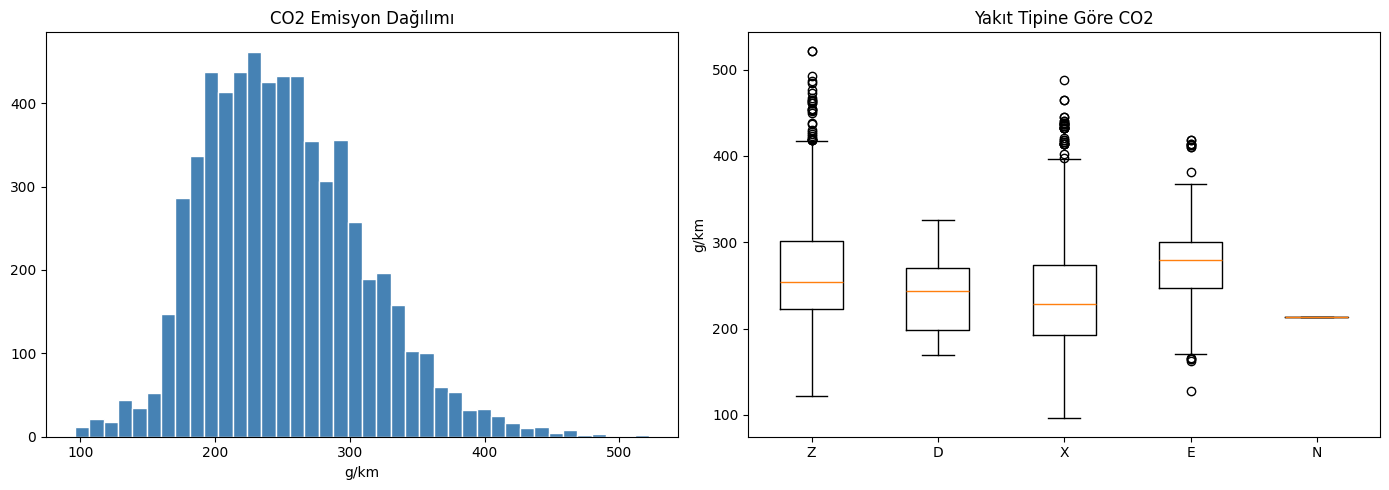

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['co2_emissionsg_km'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('CO2 Emisyon Dağılımı')
axes[0].set_xlabel('g/km')

axes[1].boxplot(
    [df[df['fuel_type'] == ft]['co2_emissionsg_km'].dropna() for ft in df['fuel_type'].unique()],
    labels=df['fuel_type'].unique()
)
axes[1].set_title('Yakıt Tipine Göre CO2')
axes[1].set_ylabel('g/km')

plt.tight_layout()
plt.show()

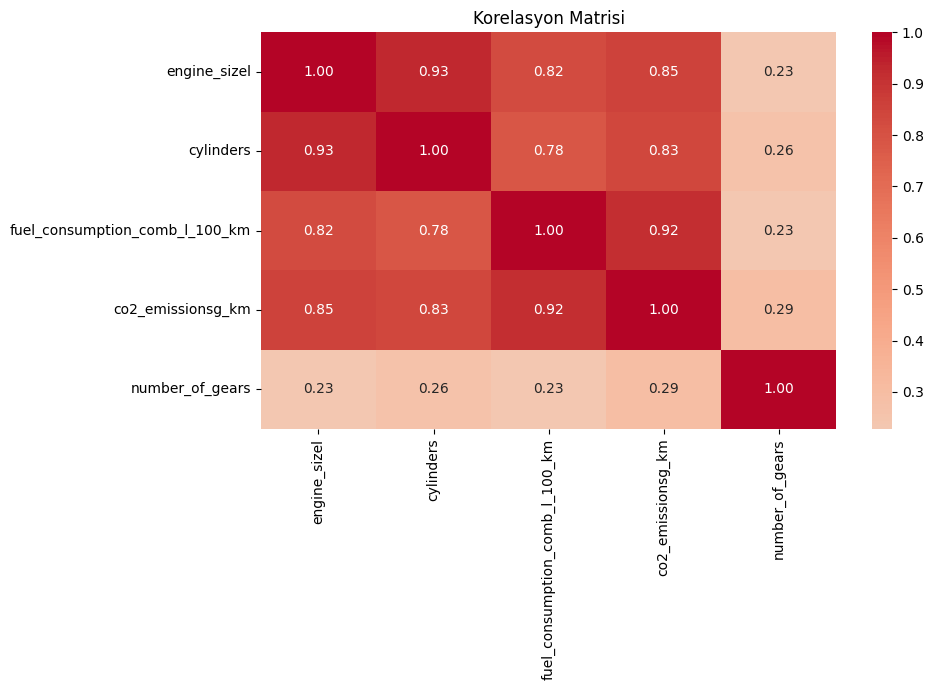


Hedef ile korelasyon (mutlak değer, azalan):
fuel_consumption_comb_l_100_km    0.916840
engine_sizel                      0.854802
cylinders                         0.834687
number_of_gears                   0.291827
Name: co2_emissionsg_km, dtype: float64


In [25]:
# Sayısal featureların hedefle korelasyonu
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

print("\nHedef ile korelasyon (mutlak değer, azalan):")
print(corr['co2_emissionsg_km'].drop('co2_emissionsg_km').abs().sort_values(ascending=False))

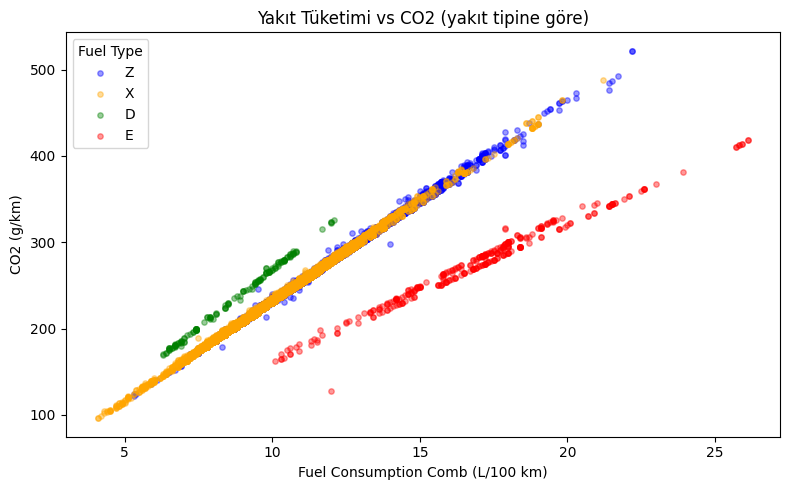

In [26]:
# Fuel consumption vs CO2 — fiziksel ilişkiyi görselleştir
plt.figure(figsize=(8, 5))
for ft, color in zip(['Z', 'X', 'D', 'E'], ['blue', 'orange', 'green', 'red']):
    subset = df[df['fuel_type'] == ft]
    plt.scatter(
        subset['fuel_consumption_comb_l_100_km'],
        subset['co2_emissionsg_km'],
        alpha=0.4, s=15, label=ft, color=color
    )
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.ylabel('CO2 (g/km)')
plt.title('Yakıt Tüketimi vs CO2 (yakıt tipine göre)')
plt.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

## 3. Multicollinearity — VIF Analizi

VIF > 10 → ciddi multicollinearity, o feature modeli bozabilir (özellikle Linear Regression için).

In [27]:
# Sadece sayısal featurelarla VIF
numeric_features = [
    'engine_sizel',
    'cylinders',
    'fuel_consumption_comb_l_100_km',
    'number_of_gears'
]

X_vif = df[numeric_features].dropna()

vif_df = pd.DataFrame()
vif_df['Feature'] = numeric_features
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df = vif_df.sort_values('VIF', ascending=False)

print(vif_df.to_string(index=False))
print("\nVIF > 10 → multicollinearity sorunu var") #çoklu baglanti sorunu
print("VIF 1-5 → kabul edilebilir")

                       Feature       VIF
                     cylinders 68.876583
                  engine_sizel 45.801012
fuel_consumption_comb_l_100_km 33.656198
               number_of_gears 11.786098

VIF > 10 → multicollinearity sorunu var
VIF 1-5 → kabul edilebilir


## 4. Feature Engineering — Fizik Tabanlı Feature

In [ ]:
fuel_co2_factor = {'Z': 2310, 'X': 2310, 'D': 2680, 'E': 1540, 'N': 1960, 'B': 0}
df['co2_factor'] = df['fuel_type'].map(fuel_co2_factor).fillna(2310)


df['theoretical_co2'] = df['fuel_consumption_comb_l_100_km'] * df['co2_factor'] / 100


df['city_hwy_ratio'] = city_col.values / hwy_col.values.clip(min=0.1)

valid = df[['theoretical_co2', 'co2_emissionsg_km']].dropna()
r2_physics = r2_score(valid['co2_emissionsg_km'], valid['theoretical_co2'])
rmse_physics = np.sqrt(mean_squared_error(valid['co2_emissionsg_km'], valid['theoretical_co2']))
print(f"Fizik formülü tek başına → R²: {r2_physics:.4f}, RMSE: {rmse_physics:.2f} g/km") #sadece fizik formülünün ne kadar doğru olduğunu gösterir

Fizik formülü tek başına → R²: 0.9926, RMSE: 5.10 g/km


## 5. Model Karşılaştırması — 4 Farklı Feature Seti

| Senaryo | Featurelar | Beklenti |
|---------|-----------|----------|
| A | Sadece fuel_cons_comb | Yüksek R² |
| B | fuel_cons_comb + fuel_type | Daha yüksek R² |
| C | Engine / Cylinders / Class / Transmission | Orta R² |
| D | theoretical_co2 (fizik feature) | En yüksek R² |

In [29]:
TARGET = 'co2_emissionsg_km'
kf = KFold(n_splits=5, shuffle=True, random_state=42)


df_enc = pd.get_dummies(df, columns=['vehicle_class', 'fuel_type', 'transmission_type'], drop_first=True)
df_enc = df_enc.dropna().reset_index(drop=True)


df_enc['fuel_consumption_city_l_100_km'] = city_col.values[:len(df_enc)]
df_enc['fuel_consumption_hwy_l_100_km']  = hwy_col.values[:len(df_enc)]

categorical_dummies = [c for c in df_enc.columns if c.startswith(('vehicle_class_', 'fuel_type_', 'transmission_type_'))]

scenarios = {
    'A: Sadece fuel_comb': ['fuel_consumption_comb_l_100_km'],
    'B: fuel_comb + fuel_type': ['fuel_consumption_comb_l_100_km'] + [c for c in categorical_dummies if c.startswith('fuel_type_')],
    'C: Motor/Silindir/Sınıf': ['engine_sizel', 'cylinders', 'number_of_gears'] + [c for c in categorical_dummies if c.startswith(('vehicle_class_', 'transmission_type_'))],
    'D: Fizik feature': ['theoretical_co2'],
    'E: City+Hwy+Comb (Hein tarzı)': ['fuel_consumption_comb_l_100_km', 'fuel_consumption_city_l_100_km', 'fuel_consumption_hwy_l_100_km'],
}

results = []
for name, features in scenarios.items():
    available = [f for f in features if f in df_enc.columns]
    X = df_enc[available].values
    y = df_enc[TARGET].values

    model = LinearRegression()
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    neg_mse = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-neg_mse.mean())

    results.append({
        'Senaryo': name,
        'R² (ort)': round(r2_scores.mean(), 4),
        'R² (std)': round(r2_scores.std(), 4),
        'RMSE (g/km)': round(rmse, 2)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                      Senaryo  R² (ort)  R² (std)  RMSE (g/km)
          A: Sadece fuel_comb    0.8401    0.0110        23.69
     B: fuel_comb + fuel_type    0.9900    0.0018         5.95
      C: Motor/Silindir/Sınıf    0.8346    0.0042        24.08
             D: Fizik feature    0.9948    0.0002         4.26
E: City+Hwy+Comb (Hein tarzı)    0.8445    0.0102        23.36


## 6. Model Karşılaştırması — Farklı Algoritmalar (En İyi Feature Setiyle)

In [30]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


best_features = (
    ['fuel_consumption_comb_l_100_km', 'engine_sizel', 'cylinders',
     'number_of_gears', 'co2_factor', 'city_hwy_ratio']
    + categorical_dummies
)
best_features = [f for f in best_features if f in df_enc.columns]

X_best = df_enc[best_features].values
y = df_enc[TARGET].values

models = {
    'Linear Regression':          LinearRegression(),
    'Ridge (α=1)':                Ridge(alpha=1.0),
    'Lasso (α=0.1)':              Lasso(alpha=0.1),
    'Poly(2) + Lin. Reg.':        Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)), ('lr', LinearRegression())]),
    'Random Forest':              RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':          GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42),
    'HistGradientBoosting':       HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=6, random_state=42),
}

model_results = []
for name, model in models.items():
    r2_scores = cross_val_score(model, X_best, y, cv=kf, scoring='r2')
    neg_mse = cross_val_score(model, X_best, y, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-neg_mse.mean())
    model_results.append({
        'Model': name,
        'R² (ort)': round(r2_scores.mean(), 4),
        'R² (std)': round(r2_scores.std(), 4),
        'RMSE (g/km)': round(rmse, 2)
    })
    print(f"  {name}: R²={r2_scores.mean():.4f}, RMSE={rmse:.2f}")

model_df = pd.DataFrame(model_results).sort_values('R² (ort)', ascending=False)
print("\n=== SONUÇ TABLOSU ===")
print(model_df.to_string(index=False))

  Linear Regression: R²=0.9917, RMSE=5.40
  Ridge (α=1): R²=0.9917, RMSE=5.40
  Lasso (α=0.1): R²=0.9907, RMSE=5.72
  Poly(2) + Lin. Reg.: R²=0.9976, RMSE=2.93
  Random Forest: R²=0.9973, RMSE=3.11
  Gradient Boosting: R²=0.9975, RMSE=3.00
  HistGradientBoosting: R²=0.9964, RMSE=3.55

=== SONUÇ TABLOSU ===
               Model  R² (ort)  R² (std)  RMSE (g/km)
 Poly(2) + Lin. Reg.    0.9976    0.0003         2.93
   Gradient Boosting    0.9975    0.0008         3.00
       Random Forest    0.9973    0.0007         3.11
HistGradientBoosting    0.9964    0.0009         3.55
   Linear Regression    0.9917    0.0009         5.40
         Ridge (α=1)    0.9917    0.0009         5.40
       Lasso (α=0.1)    0.9907    0.0013         5.72


## 7. Feature Importance — En İyi Modelden

## 7b. En İyi Model için Hyperparameter Tuning (HistGradientBoosting)

In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_iter':      [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.08, 0.1],
    'max_depth':     [4, 5, 6, 8, None],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0],
}

hgb = HistGradientBoostingRegressor(random_state=42)
search = RandomizedSearchCV(
    hgb, param_dist, n_iter=30, cv=5,
    scoring='r2', random_state=42, n_jobs=-1, verbose=0
)
search.fit(X_best, y)

print(f"En iyi parametreler: {search.best_params_}")
print(f"En iyi CV R²       : {search.best_score_:.4f}")

# Tuned modeli test seti üzerinde de değerlendir
X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=42)
tuned_model = search.best_estimator_
tuned_model.fit(X_train, y_train)
y_pred_tuned = tuned_model.predict(X_test)
print(f"Test R²            : {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Test RMSE          : {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.2f} g/km")

En iyi parametreler: {'min_samples_leaf': 10, 'max_iter': 500, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0.1}
En iyi CV R²       : 0.9954
Test R²            : 0.9958
Test RMSE          : 3.88 g/km


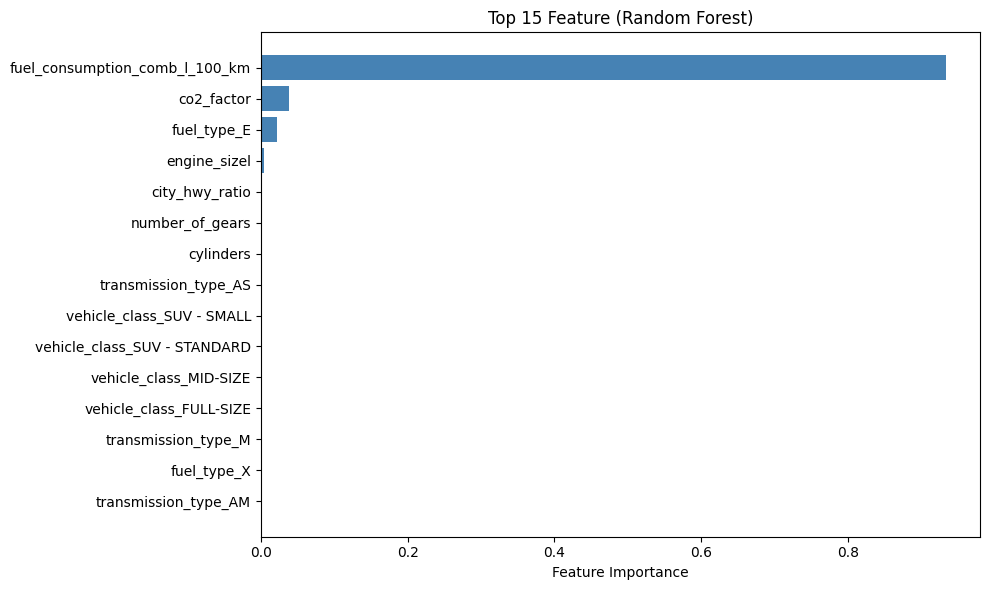

                       Feature  Importance
fuel_consumption_comb_l_100_km    0.933766
                    co2_factor    0.038028
                   fuel_type_E    0.022332
                  engine_sizel    0.004014
                city_hwy_ratio    0.000761
               number_of_gears    0.000249
                     cylinders    0.000233
          transmission_type_AS    0.000116
     vehicle_class_SUV - SMALL    0.000075
  vehicle_class_SUV - STANDARD    0.000047
        vehicle_class_MID-SIZE    0.000046
       vehicle_class_FULL-SIZE    0.000041
           transmission_type_M    0.000034
                   fuel_type_X    0.000032
          transmission_type_AM    0.000032


In [32]:
#Random Forest ile feature importance
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_best, y)

importance_df = pd.DataFrame({
    'Feature': best_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature (Random Forest)')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

## 8. Lasso ile Feature Selection

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_best)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso_cv.fit(X_scaled, y)

print(f"LassoCV optimal alpha: {lasso_cv.alpha_:.4f}")

lasso_coef = pd.DataFrame({
    'Feature': best_features,
    'Coefficient': lasso_cv.coef_
})
kept = lasso_coef[lasso_coef['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
dropped = lasso_coef[lasso_coef['Coefficient'] == 0]

print(f"\nHayatta kalan featurelar ({len(kept)}):")
print(kept.to_string(index=False))
print(f"\nLasso'nun sıfırladığı featurelar ({len(dropped)}):")
print(dropped['Feature'].tolist())

LassoCV optimal alpha: 0.0544

Hayatta kalan featurelar (26):
                              Feature  Coefficient
       fuel_consumption_comb_l_100_km    65.368363
                           co2_factor    14.197531
                          fuel_type_E   -11.558653
                            cylinders     1.159120
        vehicle_class_VAN - PASSENGER    -0.885062
            vehicle_class_VAN - CARGO    -0.830673
                      number_of_gears     0.684896
                          fuel_type_N    -0.623583
   vehicle_class_PICKUP TRUCK - SMALL     0.508503
vehicle_class_PICKUP TRUCK - STANDARD     0.447262
            vehicle_class_SUV - SMALL     0.409295
vehicle_class_SPECIAL PURPOSE VEHICLE     0.398946
                       city_hwy_ratio     0.384551
              vehicle_class_FULL-SIZE     0.244861
                         engine_sizel     0.216820
         vehicle_class_SUV - STANDARD     0.199066
                 transmission_type_AV    -0.080138
             vehicle

## 9. Sonuç — En İyi Model Performansı (Residual Analizi)

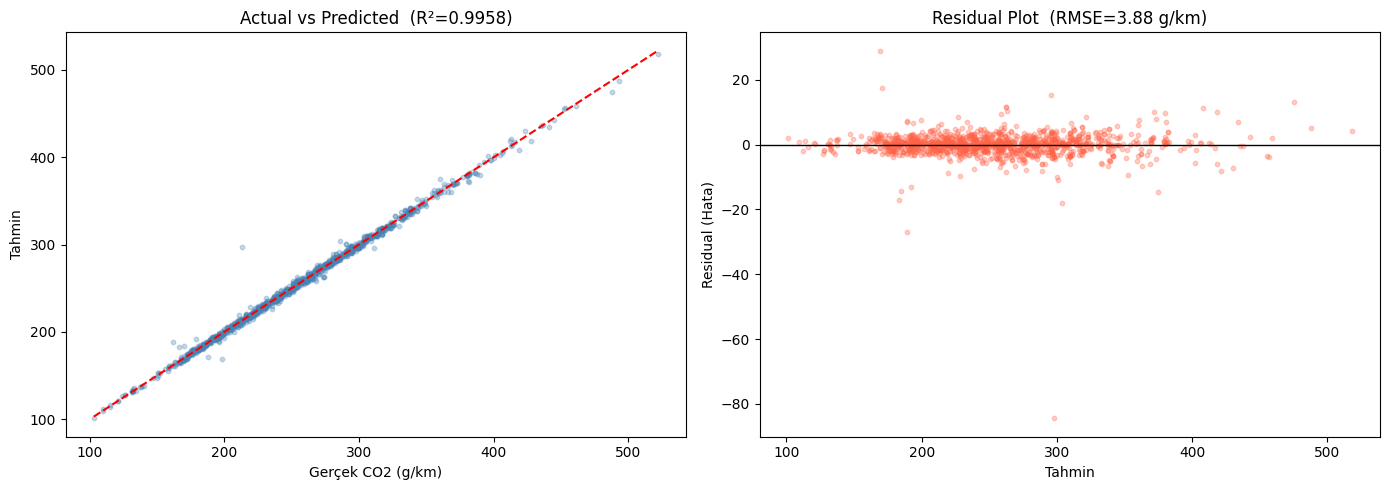

In [34]:
#görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_tuned, alpha=0.3, s=10, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[0].set_xlabel('Gerçek CO2 (g/km)')
axes[0].set_ylabel('Tahmin')
r2_final = r2_score(y_test, y_pred_tuned)
axes[0].set_title(f'Actual vs Predicted  (R²={r2_final:.4f})')

residuals = y_test - y_pred_tuned
axes[1].scatter(y_pred_tuned, residuals, alpha=0.3, s=10, color='tomato')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Residual (Hata)')
axes[1].set_title(f'Residual Plot  (RMSE={np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.2f} g/km)')

plt.tight_layout()
plt.show()

## 10. Literatür Karşılaştırması

In [35]:
#literature ile kıyas
lit = pd.DataFrame([
    {'Kaynak': 'Gurcan Fatih',            'Model': 'XGBoost',                  'R²': 0.9979, 'RMSE': 2.66},
    {'Kaynak': 'Natarajan et al.',         'Model': 'CatBoost',                 'R²': 0.9960, 'RMSE': 1.90},
    {'Kaynak': 'Guo et al.',              'Model': 'GBM',                       'R²': 0.9973, 'RMSE': 3.36},
    {'Kaynak': 'Hein et al.',             'Model': 'Multiple Linear Reg.',      'R²': 0.9990, 'RMSE': None},
    {'Kaynak': 'Hang Thi Thanh Vu',       'Model': 'Simple Linear Reg.',        'R²': 0.9930, 'RMSE': None},
    {'Kaynak': 'Sahbi Boubaker et al.',   'Model': 'Random Forest',             'R²': 0.9800, 'RMSE': None},
    {'Kaynak': 'Saraswat et al.',         'Model': 'MLP + GAO optimizer',       'R²': 0.9881, 'RMSE': 6.48},
    {'Kaynak': 'Alam et al.',             'Model': '5-fold CV model',           'R²': 0.9938, 'RMSE': None},
    {'Kaynak': 'BU ÇALIŞMADA', 'Model': 'HistGradientBoosting (tuned)',
     'R²': round(r2_score(y_test, y_pred_tuned), 4),
     'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_tuned)), 2)},
])

lit['R²'] = lit['R²'].map(lambda x: f'{x:.4f}' if x else '—')
lit['RMSE'] = lit['RMSE'].map(lambda x: f'{x:.2f}' if x else '—')
print(lit.to_string(index=False))

               Kaynak                        Model     R² RMSE
         Gurcan Fatih                      XGBoost 0.9979 2.66
     Natarajan et al.                     CatBoost 0.9960 1.90
           Guo et al.                          GBM 0.9973 3.36
          Hein et al.         Multiple Linear Reg. 0.9990  nan
    Hang Thi Thanh Vu           Simple Linear Reg. 0.9930  nan
Sahbi Boubaker et al.                Random Forest 0.9800  nan
      Saraswat et al.          MLP + GAO optimizer 0.9881 6.48
          Alam et al.              5-fold CV model 0.9938  nan
         BU ÇALIŞMADA HistGradientBoosting (tuned) 0.9958 3.88
